In [2]:
# Importing the libraries
import pandas as pd
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the dataset from google cloud
client=bigquery.Client(project="aavash-bigquery")
# observing the no of tabkes
tables=client.list_tables("bigquery-public-data.thelook_ecommerce")
for table in tables:
    print(table.table_id)


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


distribution_centers
events
inventory_items
order_items
orders
products
thelook_ecommerce-table
users


# There are 8 tables in total but for analyzing this dataset from a business point of view only 4 of them seems important 
->Users
->Products
->Orders
->Order_items

In [34]:
# Observing the first 4 tables
query_1="""
SELECT *
FROM `bigquery-public-data.thelook_ecommerce.users`
LIMIT 10
"""
df_users=client.query(query_1).to_dataframe()
df_users


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,user_geom
0,61089,Erica,Haney,ericahaney@example.org,16,F,Acre,280 Spencer Gardens,69980-000,null,Brasil,-8.065346,-72.870949,Search,2023-04-22 17:46:00+00:00,POINT(-72.87094866 -8.065346116)
1,30171,Jay,Patterson,jaypatterson@example.net,53,M,Acre,1264 Christopher Spring Suite 143,69980-000,null,Brasil,-8.065346,-72.870949,Search,2024-02-07 18:46:00+00:00,POINT(-72.87094866 -8.065346116)
2,47873,Scott,Jacobson,scottjacobson@example.com,22,M,Acre,7764 Ross Overpass,69980-000,null,Brasil,-8.065346,-72.870949,Search,2020-03-14 03:23:00+00:00,POINT(-72.87094866 -8.065346116)
3,40378,Jacob,Rhodes,jacobrhodes@example.net,16,M,Acre,88834 Michelle Summit,69980-000,null,Brasil,-8.065346,-72.870949,Facebook,2021-02-14 02:45:00+00:00,POINT(-72.87094866 -8.065346116)
4,76164,Dorothy,Burgess,dorothyburgess@example.net,48,F,Acre,4011 Daniel Roads,69980-000,null,Brasil,-8.065346,-72.870949,Search,2026-03-06 14:24:00+00:00,POINT(-72.87094866 -8.065346116)
5,21212,Veronica,Mcdaniel,veronicamcdaniel@example.org,38,F,Acre,2232 Mcdaniel Orchard Apt. 119,69980-000,null,Brasil,-8.065346,-72.870949,Email,2022-04-15 07:25:00+00:00,POINT(-72.87094866 -8.065346116)
6,42435,Stephen,Gardner,stephengardner@example.net,58,M,Acre,2896 Nguyen Mountain,69980-000,null,Brasil,-8.065346,-72.870949,Search,2020-07-02 10:42:00+00:00,POINT(-72.87094866 -8.065346116)
7,2630,Michael,Gray,michaelgray@example.com,28,M,Acre,36777 Forbes Route,69980-000,null,Brasil,-8.065346,-72.870949,Search,2021-02-16 06:48:00+00:00,POINT(-72.87094866 -8.065346116)
8,50387,Tammy,Cisneros,tammycisneros@example.org,33,F,Acre,320 Jennifer Wall,69980-000,null,Brasil,-8.065346,-72.870949,Search,2020-06-24 03:33:00+00:00,POINT(-72.87094866 -8.065346116)
9,97354,Amanda,Murphy,amandamurphy@example.net,59,F,Acre,315 Rangel Island Apt. 333,69980-000,null,Brasil,-8.065346,-72.870949,Email,2022-01-04 01:39:00+00:00,POINT(-72.87094866 -8.065346116)


In [5]:
# Growth of company by year on the basis of completed sales
# Revenue by month
query_orders="""
SELECT *
FROM `bigquery-public-data.thelook_ecommerce.orders`
LIMIT 10
"""
df_orders=client.query(query_orders).to_dataframe()
query_order_items="""
SELECT *
FROM `bigquery-public-data.thelook_ecommerce.order_items`
LIMIT 10
"""
print(df_orders)
df_order_items=client.query(query_order_items).to_dataframe()
df_order_items

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   order_id  user_id     status gender                created_at returned_at  \
0         1        1  Cancelled      F 2024-10-12 15:21:15+00:00         NaT   
1        17       12  Cancelled      F 2024-11-13 13:38:10+00:00         NaT   
2        46       35  Cancelled      F 2026-03-09 03:19:26+00:00         NaT   
3        96       78  Cancelled      F 2025-12-17 19:05:38+00:00         NaT   
4       103       81  Cancelled      F 2025-12-22 21:13:22+00:00         NaT   
5       176      147  Cancelled      F 2024-07-26 07:19:38+00:00         NaT   
6       181      150  Cancelled      F 2023-10-11 11:21:33+00:00         NaT   
7       199      162  Cancelled      F 2026-03-26 13:19:44+00:00         NaT   
8       202      164  Cancelled      F 2024-08-29 23:40:16+00:00         NaT   
9       205      165  Cancelled      F 2022-05-07 12:01:01+00:00         NaT   

  shipped_at delivered_at  num_of_item  
0        NaT          NaT            1  
1        NaT          NaT            

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,92745,63950,51233,14235,249987,Complete,2022-08-30 02:42:35+00:00,2022-09-01 02:37:14+00:00,2022-09-03 12:18:14+00:00,NaT,0.02
1,175905,121189,96693,14235,474137,Complete,2022-07-14 18:58:05+00:00,2022-07-16 04:15:57+00:00,2022-07-19 06:02:57+00:00,NaT,0.02
2,47756,32910,26329,14235,128932,Processing,2021-08-24 21:22:22+00:00,NaT,NaT,NaT,0.02
3,49401,34050,27267,14235,133342,Processing,2021-02-28 13:51:37+00:00,NaT,NaT,NaT,0.02
4,99332,68492,54919,14235,267741,Processing,2023-05-19 19:30:47+00:00,NaT,NaT,NaT,0.02
5,15366,10534,8384,14235,41425,Shipped,2023-05-08 03:14:37+00:00,2023-05-10 21:55:14+00:00,NaT,NaT,0.02
6,95307,65694,52683,14235,256930,Shipped,2026-05-20 05:21:26+00:00,2026-05-20 03:20:39+00:00,NaT,NaT,0.02
7,110040,75868,60667,14235,296579,Shipped,2021-11-22 21:11:08+00:00,2021-11-21 03:42:19+00:00,NaT,NaT,0.02
8,125477,86483,69043,14235,338373,Shipped,2022-01-08 13:21:50+00:00,2022-01-06 22:42:16+00:00,NaT,NaT,0.02
9,92985,64106,51372,14159,250640,Cancelled,2024-10-06 03:07:49+00:00,NaT,NaT,NaT,0.49


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


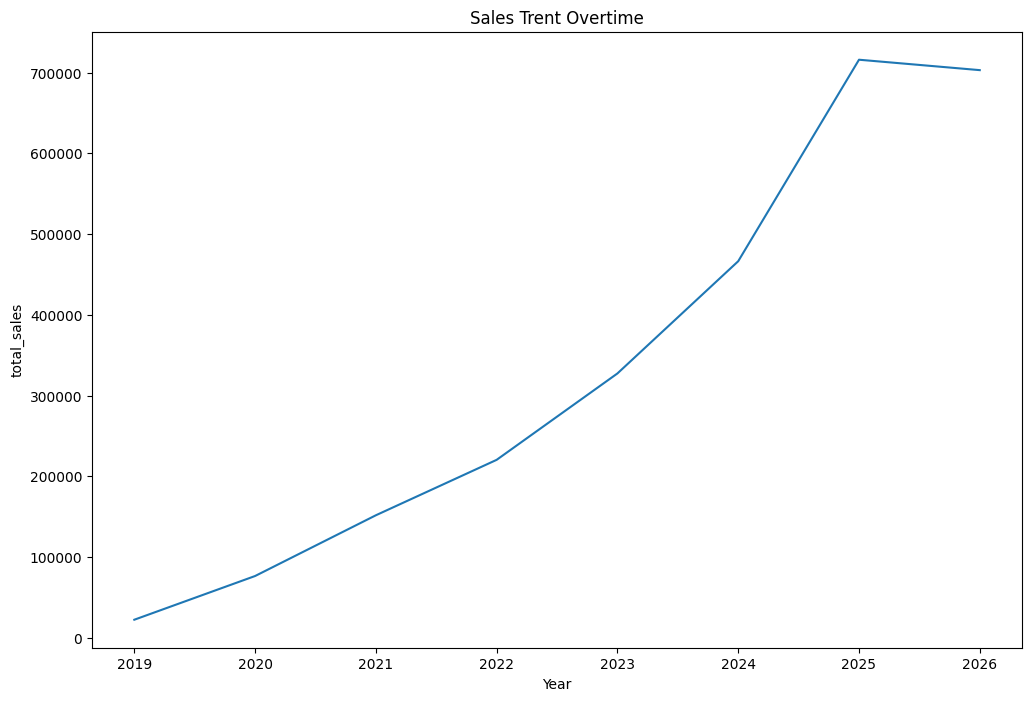

,Year,total_sales,growth_rate
0,2019,22442.010044,NaN
1,2020,76572.450096,241.201389
2,2021,151791.550086,98.232589
3,2022,220445.920329,45.229376
4,2023,327433.220227,48.532220
5,2024,466395.940575,42.440019
6,2025,715935.400645,53.503780
7,2026,703034.980747,-1.801897


In [6]:
# Query to merge the two dataframes and prepare a chart on the growth in yearly basis
query_monthly_revenue="""
SELECT EXTRACT(YEAR FROM created_at) AS Year,SUM(sale_price) as total_sales
FROM `bigquery-public-data.thelook_ecommerce.order_items`
WHERE status="Complete"
GROUP BY Year
ORDER BY Year 

"""
highest_selling_months=client.query(query_monthly_revenue).to_dataframe()
highest_selling_months
highest_selling_months['growth_rate'] = (
    highest_selling_months['total_sales'].pct_change() * 100
)


# Line graph of sales overtime
plt.figure(figsize=(12,8))
sns.lineplot(x="Year",y="total_sales",data=highest_selling_months)
plt.xlabel("Year")
plt.ylabel("total_sales")
plt.title("Sales Trent Overtime")
plt.show()
highest_selling_months

The Sales seems to be dropping from 2025 to 2026 but 2026 data isnt fully recorded yet we need the actual comparison by comparing the monthly sales of 2025 to 2026 on the basis of months of 2026

In [7]:
# Viewing the sales of 2025 from jan-june
# Viewing the highest month of 2026
highest_month="""
SELECT MAX(EXTRACT(MONTH FROM created_at)) as max_month
FROM `bigquery-public-data.thelook_ecommerce.order_items`
WHERE EXTRACT(YEAR FROM created_at)=2026
"""
max_month=client.query(highest_month).to_dataframe()
print(max_month)
# The latest month recorded is till june. lets continue the work...
query_janjune="""
SELECT SUM(sale_price) as total_sales
FROM `bigquery-public-data.thelook_ecommerce.order_items`
WHERE status="Complete" and created_at>="2025-01-01" and created_at<"2025-06-21"
"""
total_sales_janjune=client.query(query_janjune).to_dataframe()


# The total sales in 2025(jan-june) is 304248.900 which is 383138.89 less which shows 2026 is getting better response than 2025 and there is no problem in sales.

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   max_month
0          6


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [8]:
# Top selling products and categories and Does the most selling product belong to the most selling category?
# loading products table
query_product="""
SELECT *
FROM `bigquery-public-data.thelook_ecommerce.products`
LIMIT 10
"""
df_products=client.query(query_product).to_dataframe()
df_products
# We need to find top selling product by quantity and by sales 
query_revenue="""
SELECT p.name,SUM(oi.sale_price) as total_sales
FROM `bigquery-public-data.thelook_ecommerce.products` as p
INNER JOIN `bigquery-public-data.thelook_ecommerce.order_items` as oi
on p.id=oi.product_id
WHERE oi.status="Complete"
GROUP BY p.name
ORDER BY total_sales DESC
"""
sales_product=client.query(query_revenue).to_dataframe()
sales_product


,name,total_sales
0,Darla,4995.00
1,Diesel Men's Lophophora Leather Jacket,4490.00
2,NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outst...,3612.00
3,The North Face Apex Bionic Soft Shell Jacket -...,2709.00
4,The North Face Freedom Mens Ski Pants 2013,2709.00
...,...,...
21777,Motherhood Maternity: Bra Back Extender,1.98
21778,Individual Bra Extenders,1.75
21779,Wayfarer Style Sunglasses Dark Lens Black Frame,1.50
21780,Set of 2 - Replacement Insert For Checkbook Wa...,0.98


The product with the highest contribution in sales is The North Face Apex Soft shell jacket contributing almost $6321 in sales

In [9]:
# Top category by revenue
query_category="""
SELECT p.category,SUM(oi.sale_price) as total_sales
FROM `bigquery-public-data.thelook_ecommerce.products` as p
INNER JOIN `bigquery-public-data.thelook_ecommerce.order_items` as oi
on p.id=oi.product_id
WHERE oi.status="Complete"
GROUP BY p.category
ORDER BY total_sales DESC
"""
sales_category=client.query(query_category).to_dataframe()
sales_category



c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category,total_sales
0,Outerwear & Coats,334775.619692
1,Jeans,307953.700379
2,Sweaters,210824.780020
3,Swim,160759.170209
4,Fashion Hoodies & Sweatshirts,160419.770199
5,Suits & Sport Coats,156669.199696
6,Sleep & Lounge,139762.880346
7,Shorts,130342.980448
8,Tops & Tees,121700.990551
9,Dresses,115531.130282


The highest-revenue category was Outerwear & Coats, and several of the top-performing products belonged to this category, indicating strong customer demand for outerwear products.

In [10]:
df_order_items
query_month="""
SELECT FORMAT_DATE("%B", created_at) as Month,SUM(sale_price) as total_sales
FROM `bigquery-public-data.thelook_ecommerce.order_items`
WHERE status="Complete"
GROUP BY Month
ORDER BY total_sales DESC
"""
order_month=client.query(query_month).to_dataframe()
order_month

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,Month,total_sales
0,June,371407.990454
1,May,275539.830174
2,March,245839.170254
3,April,239456.370249
4,January,225637.390187
5,February,214145.660264
6,December,212079.490216
7,October,192321.240304
8,November,190946.720186
9,August,179293.270234


June has contributed highest to sales among all months

In [14]:
# Country contibution to sales
query_country_sales="""
SELECT u.country as country,SUM(oi.sale_price) as total_sales
from `bigquery-public-data.thelook_ecommerce.order_items` as oi
JOIN `bigquery-public-data.thelook_ecommerce.users` as u
on u.id=oi.user_id
WHERE oi.status="Complete"
GROUP BY country
ORDER BY total_sales DESC

"""
country_sales=client.query(query_country_sales).to_dataframe()
 # From the result china contributed the most lets see it in %
total_percent_bychina=(country_sales.loc[0,["total_sales"]]/country_sales["total_sales"].sum())*100
top_three_countries=(country_sales.loc[0:2,["total_sales"]]/country_sales["total_sales"].sum())*100
# Finding what percent is the top 3 countries contribute in sales
print(f" Total percent of sales contibuted by china ->{total_percent_bychina["total_sales"]}")
print(f"The total % contibuted by top 3 countries ->{top_three_countries["total_sales"].sum()}")


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 Total percent of sales contibuted by china ->34.00310688851462
The total % contibuted by top 3 countries ->71.11618988686385


China contibutes the largest in sales around 34% of total revenue and The top three countries (China, the US, and Brazil) account for nearly 70% of total revenue. This suggests that a significant portion of the business's sales comes from a relatively small number of markets.

In [28]:
# Analyzing users table(users with highest number of products bought/consistent users)
df_order_items
query_highpaying_users="""
WITH highpaying_users AS (
    SELECT
        user_id,
        SUM(sale_price) AS revenue_generated
    FROM `bigquery-public-data.thelook_ecommerce.order_items`
    WHERE status = "Complete"
    GROUP BY user_id
)

SELECT
    CONCAT (u.first_name,' ',u.last_name) as full_name,
    cu.user_id,
    cu.revenue_generated
FROM highpaying_users AS cu
JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
ON cu.user_id = u.id
ORDER BY cu.revenue_generated DESC
LIMIT 20;
"""
highpaying_users=client.query(query_highpaying_users).to_dataframe()
highpaying_users


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,full_name,user_id,revenue_generated
0,Francis Wiley,39504,1469.110005
1,Thomas Cameron,27853,1260.490002
2,Stacey Barnett,96328,1205.000000
3,Harold Brown,17200,1151.979996
4,Rick Houston,7003,1142.990005
5,Kenneth Martin,66212,1131.649999
6,Kenneth Conway,11528,1124.000000
7,Stephen Mitchell,11750,1067.950001
8,Gary Johnston,7234,1065.000000
9,Crystal Chandler,16853,1063.940002


Revenue among the top 20 customers is fairly evenly distributed, indicating that the business is not heavily dependent on a single high-value customer.

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


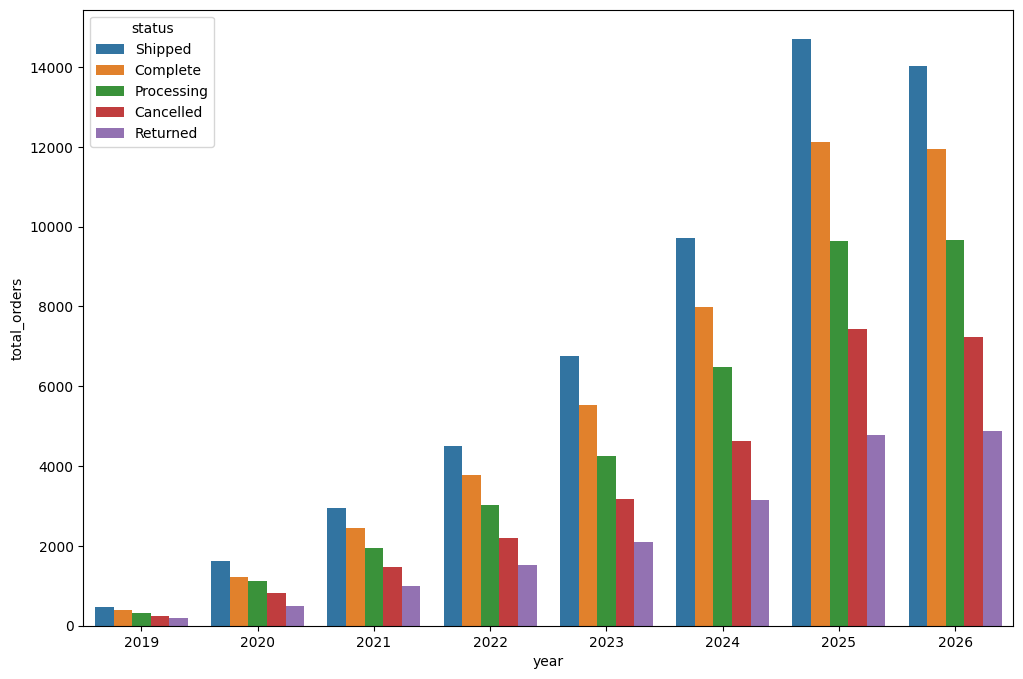

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,92745,63950,51233,14235,249987,Complete,2022-08-30 02:42:35+00:00,2022-09-01 02:37:14+00:00,2022-09-03 12:18:14+00:00,NaT,0.02
1,175905,121189,96693,14235,474137,Complete,2022-07-14 18:58:05+00:00,2022-07-16 04:15:57+00:00,2022-07-19 06:02:57+00:00,NaT,0.02
2,47756,32910,26329,14235,128932,Processing,2021-08-24 21:22:22+00:00,NaT,NaT,NaT,0.02
3,49401,34050,27267,14235,133342,Processing,2021-02-28 13:51:37+00:00,NaT,NaT,NaT,0.02
4,99332,68492,54919,14235,267741,Processing,2023-05-19 19:30:47+00:00,NaT,NaT,NaT,0.02
5,15366,10534,8384,14235,41425,Shipped,2023-05-08 03:14:37+00:00,2023-05-10 21:55:14+00:00,NaT,NaT,0.02
6,95307,65694,52683,14235,256930,Shipped,2026-05-20 05:21:26+00:00,2026-05-20 03:20:39+00:00,NaT,NaT,0.02
7,110040,75868,60667,14235,296579,Shipped,2021-11-22 21:11:08+00:00,2021-11-21 03:42:19+00:00,NaT,NaT,0.02
8,125477,86483,69043,14235,338373,Shipped,2022-01-08 13:21:50+00:00,2022-01-06 22:42:16+00:00,NaT,NaT,0.02
9,92985,64106,51372,14159,250640,Cancelled,2024-10-06 03:07:49+00:00,NaT,NaT,NaT,0.49


In [32]:
df_order_items
query_dist="""
SELECT
    EXTRACT(YEAR FROM created_at) AS year,
    status,
    COUNT(*) AS total_orders
FROM `bigquery-public-data.thelook_ecommerce.order_items`
GROUP BY year, status
ORDER BY year, total_orders DESC;
"""
df_dist=client.query(query_dist).to_dataframe()
df_dist
plt.figure(figsize=(12,8))
sns.barplot(x="year",y="total_orders",hue="status",data=df_dist)
plt.xlabel("year")
plt.ylabel("total_orders")
plt.show()
df_order_items


"The distribution of order statuses remained relatively consistent across the years, with the proportion of completed, shipped, cancelled, and returned orders showing little variation despite an increase in total order volume."

In [33]:
# Cancellation rate over the years
cancellation_query="""
SELECT EXTRACT(year FROM created_at) as Year,count(*) as total_orders,COUNTIF(status="Cancelled") as cancelled_orders,ROUND(COUNTIF(status="Cancelled")/COUNT(*)*100,2) as cancellation_rate
FROM  `bigquery-public-data.thelook_ecommerce.order_items`
GROUP BY Year
ORDER BY Year
"""
cancellation_df=client.query(cancellation_query).to_dataframe()
cancellation_df

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,Year,total_orders,cancelled_orders,cancellation_rate
0,2019,1630,240,14.72
1,2020,5273,810,15.36
2,2021,9805,1459,14.88
3,2022,15004,2195,14.63
4,2023,21827,3183,14.58
5,2024,31955,4624,14.47
6,2025,48672,7431,15.27
7,2026,47768,7243,15.16


Although the total number of orders increased substantially from 1,630 in 2019 to over 47,000 in 2026, the cancellation rate showed little variation, suggesting that operational performance scaled consistently as order volume grew.